Connect Python with MySQL

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector


db = mysql.connector.connect(host = "localhost",
                            username = "root",
                            password = "123456789",
                            database = "ecommerce")

cur = db.cursor()

Which payment method generates the highest revenue in each state?

In [40]:
query="""with cte as (select c.customer_state,
op.payment_type ,
round(sum(op.payment_value),2) as amount,
rank()over( partition by customer_state order by round(sum(payment_value),2) desc) as rnk
from order_payments op
join orders o 
on op.order_id=o.order_id
join customers c 
on c.customer_id=o.customer_id
group by c.customer_state,
op.payment_type
)
select customer_state,
payment_type ,amount
from cte
where rnk=1
order by amount desc ,customer_state """
cur.execute(query)
data=cur.fetchall(
)
df=pd.DataFrame(data, columns=["customer_state","payment_type","amount"])
df.head()


,customer_state,payment_type,amount
0,SP,credit_card,4676662.34
1,RJ,credit_card,1730340.68
2,MG,credit_card,1471975.31
3,RS,credit_card,662551.39
4,PR,credit_card,626606.74


For each state, calculate the Total Customers,Total Orders,Total Revenue,Average Revenue per Customer.

In [60]:
query="""select c.customer_state,
count(distinct c.customer_id) as total_customer,
count(distinct o.order_id) as total_orders,
round(sum(op.payment_value),2)as total_revenue,
round((round(sum(op.payment_value),2)/
count(distinct c.customer_id)),2) as avg_revenue_per_customer
from order_payments op
join orders o 
on op.order_id=o.order_id
join customers c 
on c.customer_id=o.customer_id
group by c.customer_state
order by total_revenue desc

"""
cur.execute(query)
data=cur.fetchall(
)
df=pd.DataFrame(data, columns=["customer_state","total_customer","total_orders","total_revenue","avg_revenue_per_customer"])
df

,customer_state,total_customer,total_orders,total_revenue,avg_revenue_per_customer
0,SP,41745,41745,5998226.96,143.69
1,RJ,12852,12852,2144379.69,166.85
2,MG,11635,11635,1872257.26,160.92
3,RS,5466,5466,890898.54,162.99
4,PR,5045,5045,811156.38,160.78
5,SC,3637,3637,623086.43,171.32
6,BA,3380,3380,616645.82,182.44
7,DF,2140,2140,355141.08,165.95
8,GO,2020,2020,350092.31,173.31
9,ES,2033,2033,325967.55,160.34


Find the total sales per category. 

In [42]:
query = """ SELECT 
CONCAT(
    UPPER(LEFT(t.product_category_name_english,1)),
    LOWER(SUBSTRING(t.product_category_name_english,2))
) as Cateogry,
round(sum(payment_value),1) as Total_sales
from category_translation t
join products p
on t.product_category_name=p.product_category_name
join order_items o
on p.product_id=o.product_id
join order_payments op
on op.order_id=o.order_id
group by t.product_category_name_english
order by Total_sales desc
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Category", "Total_sales"])
df.head()

,Category,Total_sales
0,Bed_bath_table,1712553.7
1,Health_beauty,1657373.1
2,Computers_accessories,1585330.4
3,Furniture_decor,1430176.4
4,Watches_gifts,1429216.7


Count the number of orders placed in 2017.


In [43]:


query="""select MONTHNAME(order_purchase_timestamp) AS month,
count(order_id) as total_orders from orders 
where year(order_purchase_timestamp) = 2018
group by month(order_purchase_timestamp), MONTHNAME(order_purchase_timestamp)
order by MONTH(order_purchase_timestamp) """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Months","Total_orders"])
df

,Months,Total_orders
0,January,7269
1,February,6728
2,March,7211
3,April,6939
4,May,6873
5,June,6167
6,July,6292
7,August,6512
8,September,16
9,October,4


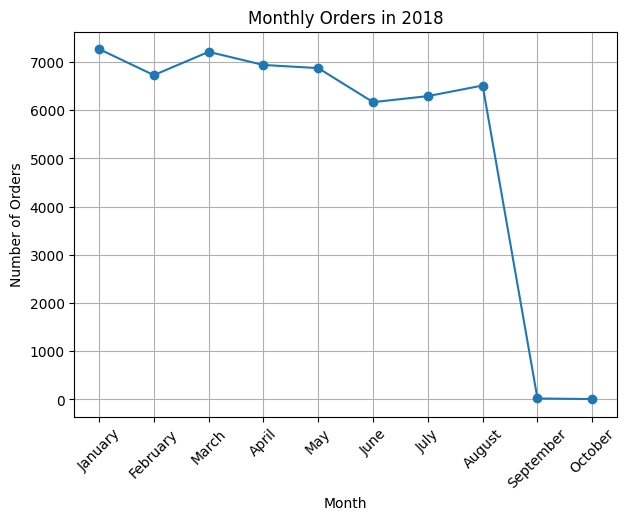

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(df["Months"], df["Total_orders"], marker="o")
plt.title("Monthly Orders in 2018")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Calculate the percentage of orders paid by each payment type.

In [45]:
query="""select round((sum(case when payment_type="boleto" then 1 else 0 end)/count(order_id))*100,2) as cash_payment,
round((sum(case when payment_type="credit_card" then 1 else 0 end)/count(order_id))*100 ,2) as credit_card_payment,
round((sum(case when payment_type="voucher" then 1 else 0 end)/count(order_id))*100 ,2) as voucher_payment,
round((sum(case when payment_type="debit_card" then 1 else 0 end)/count(order_id))*100 ,2) as debit_card_payment
from order_payments"""

cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["cash_payment"," credit_card_payment","voucher_payment","debit_card_payment"])
df.style.hide(axis="index")
df

,cash_payment,credit_card_payment,voucher_payment,debit_card_payment
0,19.04,73.92,5.56,1.47


In [46]:
"""
Insights -
1.Targeted cashback or discount offers on Debit Card payments could increase customer adoption.
2.Credit Card is the most preferred payment method
"""

'\nInsights -\n1.Targeted cashback or discount offers on Debit Card payments could increase customer adoption.\n2.Credit Card is the most preferred payment method\n'

Find the average number of products per order, grouped by customer city.

In [47]:
query=""" with cte as(select ot.order_id,
count(p.product_id) as product_count
from products p
join order_items ot
on p.product_id=ot.product_id
group by ot.order_id
)

select c.customer_city,
round(avg(product_count),2) as avg_products
from customers c
join orders o
on c.customer_id=o.customer_id
join cte ct
on ct.order_id=o.order_id
group by c.customer_city
ORDER BY avg_products DESC  """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["City","Avg_products"])
df

,City,Avg_products
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
...,...,...
4105,rio dos indios,1.00
4106,bela vista do maranhao,1.00
4107,centro novo do maranhao,1.00
4108,humberto de campos,1.00


In [48]:
"""
Insights-
1.Customers in some cities buy more products in one order.
2.Marketing Strategy in city where order are less places
"""

'\nInsights-\n1.Customers in some cities buy more products in one order.\n2.Marketing Strategy in city where order are less places\n'

Classify products into Price Categories (Low, Medium, High) and compare their average purchase frequency


In [49]:
query=""" with cte as(select product_id,
avg(price) avg_price ,
count(order_id) purchase_count
from order_items
group by product_id
)
select 
case when avg_price<100 then "Low Price"
 when avg_price between 100 and 400 then "Mid Price"
else "High Price"  end as price_category,
round(avg(purchase_count),2) as avg_purchase_frequency
from cte
group by price_category
ORDER BY
CASE
    WHEN price_category='Low Price' THEN 1
    WHEN price_category='Medium Price' THEN 2
    ELSE 3
END;  """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["price_category","avg_purchase_frequency"])
df


,price_category,avg_purchase_frequency
0,Low Price,3.57
1,Mid Price,3.37
2,High Price,2.16


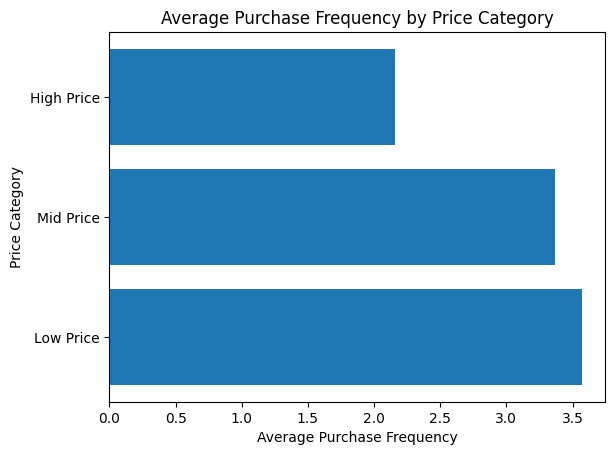

In [50]:
import matplotlib.pyplot as plt
plt.barh(df["price_category"],df["avg_purchase_frequency"])
plt.title("Average Purchase Frequency by Price Category")
plt.xlabel("Average Purchase Frequency")
plt.ylabel("Price Category")
plt.show()

In [51]:
"""
Insights -
1.Customers mostly buy low-priced products.
2.High-priced products sell less frequently.
3.Premium products may need stronger marketing.
"""

'\nInsights -\n1.Customers mostly buy low-priced products.\n2.High-priced products sell less frequently.\n3.Premium products may need stronger marketing.\n'

Calculate the total revenue generated by each seller, and rank them by revenue.


In [52]:
query=""" with cte as(select ot.seller_id,
round(sum(op.payment_value),2) as total
from order_items ot
join order_payments op
on ot.order_id=op.order_id
group by ot.seller_id
)
select *, dense_rank()over(order by total desc) as rnk
from cte """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["seller_id","Total","Rank"])
df.head(10)

,seller_id,Total,Rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
5,da8622b14eb17ae2831f4ac5b9dab84a,272219.32,6
6,4869f7a5dfa277a7dca6462dcf3b52b2,264166.12,7
7,955fee9216a65b617aa5c0531780ce60,236322.30,8
8,fa1c13f2614d7b5c4749cbc52fecda94,206513.23,9
9,7e93a43ef30c4f03f38b393420bc753a,185134.21,10


Identify the top 3 customers who spent the most money in each year.

In [53]:
query="""with cte as(select year(o.order_purchase_timestamp) as years, round(sum(op.payment_value),1) as total,
o.customer_id, dense_rank() over(partition by year(order_purchase_timestamp) 
order by sum(payment_value) desc) as rnk
from orders o
join order_payments op
on o.order_id=op.order_id
group by year(o.order_purchase_timestamp),o.customer_id
)
select years,total,customer_id 
from cte 
where rnk<=3"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Year","Total","Customer_id"])
df

,Year,Total,Customer_id
0,2016,1423.6,a9dc96b027d1252bbac0a9b72d837fc6
1,2016,1400.7,1d34ed25963d5aae4cf3d7f3a4cda173
2,2016,1227.8,4a06381959b6670756de02e07b83815f
3,2017,13664.1,1617b1357756262bfa56ab541c47bc16
4,2017,6929.3,c6e2731c5b391845f6800c97401a43a9
5,2017,6726.7,3fd6777bbce08a352fddd04e4a7cc8f6
6,2018,7274.9,ec5b2ba62e574342386871631fafd3fc
7,2018,6922.2,f48d464a0baaea338cb25f816991ab1f
8,2018,4809.4,e0a2412720e9ea4f26c1ac985f6a7358


 Calculate the cumulative sales per month for each year.

In [54]:
query="""with cte as
(
SELECT
YEAR(o.order_purchase_timestamp) AS year,
MONTH(o.order_purchase_timestamp) AS month,
ROUND(SUM(op.payment_value),2) AS monthly_sales
FROM orders o
JOIN order_payments op
ON o.order_id = op.order_id
GROUP BY
YEAR(o.order_purchase_timestamp),
MONTH(o.order_purchase_timestamp)
)
SELECT year,month,monthly_sales,
ROUND(SUM(monthly_sales)OVER(
PARTITION BY year
ORDER BY month),2) AS cumulative_sales
from cte
ORDER BY year,month;"""
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Year","month","monthly_sales"," cumulative_sales"])
df


,Year,month,monthly_sales,cumulative_sales
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,138488.04
4,2017,2,291908.01,430396.05
5,2017,3,449863.60,880259.65
6,2017,4,417788.03,1298047.68
7,2017,5,592918.82,1890966.50
8,2017,6,511276.38,2402242.88
9,2017,7,592382.92,2994625.80


Which states have the highest Average Order Value (AOV)

In [55]:
query=""" 
select c.customer_state,
round((sum(op.payment_value)/count(distinct o.order_id)),2) as aov
from  order_payments op
join orders o
on o.order_id=op.order_id
join customers c
on c.customer_id=o.customer_id
group by c.customer_state
order by aov desc """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["state","average_order_value"])
df.head()

,state,average_order_value
0,PB,264.08
1,AC,242.97
2,RO,240.58
3,AP,239.16
4,AL,234.77


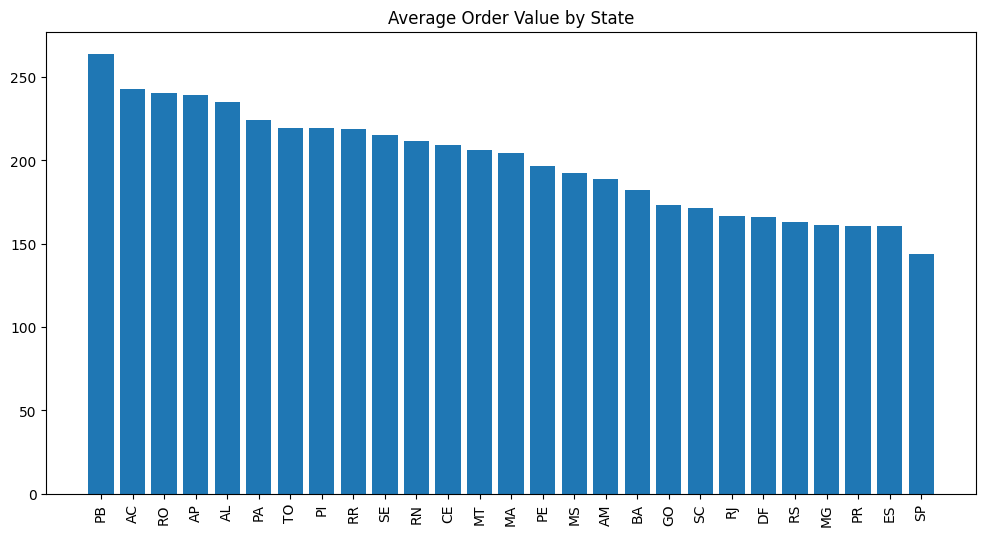

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(df["state"],df["average_order_value"])
plt.xticks(rotation=90)
plt.title("Average Order Value by State")
plt.show()

Which states have the longest average delivery time?

In [ ]:
query=""" 
select c.customer_state,
round(avg(datediff(o.order_delivered_customer_date,o.order_purchase_timestamp )),2) as average_delivery_time
from  customers c
join orders o
on c.customer_id=o.customer_id
where order_delivered_customer_date is not null
group by c.customer_state
order by average_delivery_time desc
 """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["customer_state","average_delivery_time"])
df

,customer_state,average_delivery_time
0,RR,29.34
1,AP,27.18
2,AM,26.36
3,AL,24.50
4,PA,23.73
5,MA,21.51
6,SE,21.46
7,CE,21.20
8,AC,21.00
9,PB,20.39


Which product categories have the lowest customer ratings?

In [62]:
query=""" 
SELECT ct.product_category_name_english,
round(avg(ov.review_score),2) as avg_rating
FROM category_translation ct
join products p
on p.product_category_name=ct.product_category_name_english
join order_items oi
on oi.product_id=p.product_id
join order_reviews ov
on ov.order_id=oi.order_id
group by ct.product_category_name_english
order by avg_rating desc

 """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Category","avg_rating"])
df

,Category,avg_rating
0,pet_shop,4.19
1,cool_stuff,4.15
2,dvds_blu_ray,4.08
3,market_place,4.02
4,consoles_games,4.02
5,la_cuisine,4.00
6,audio,3.83


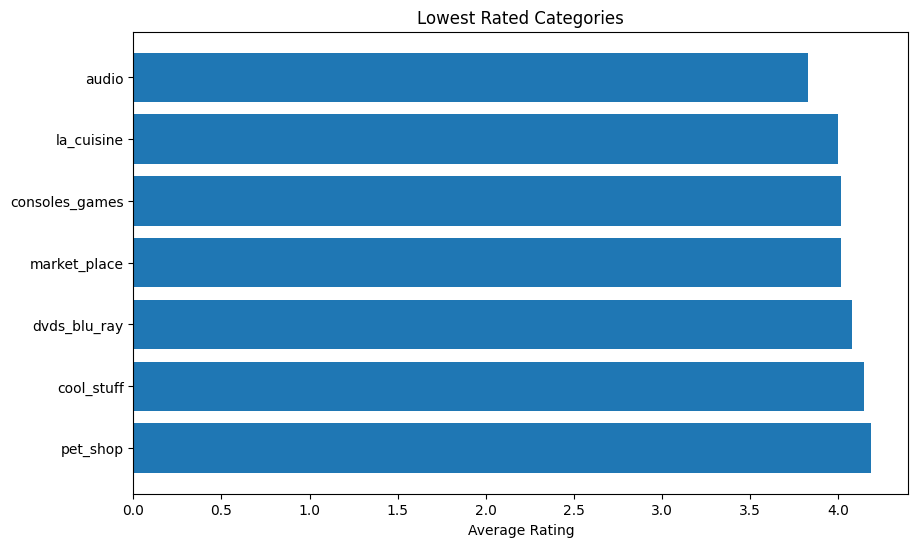

In [64]:
plt.figure(figsize=(10,6))
plt.barh(df["Category"],df["avg_rating"])
plt.title("Lowest Rated Categories")
plt.xlabel("Average Rating")
plt.show()

Does delivery time affect customer ratings?

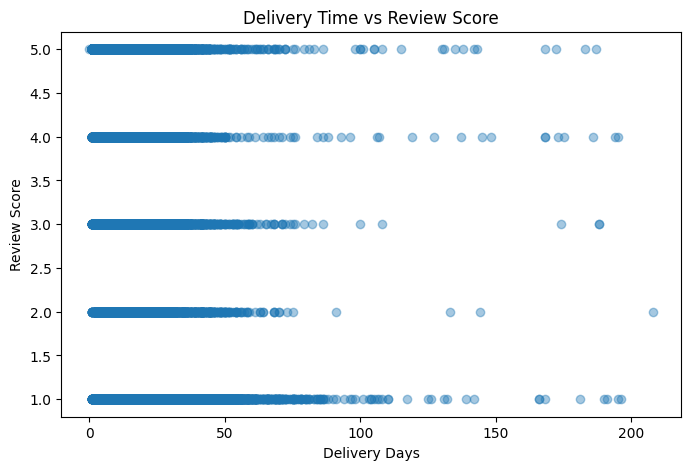

In [ ]:
c

plt.figure(figsize=(8,5))
plt.scatter(df["delivery_days"],df["review_score"],alpha=0.4)
plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.show()

In [ ]:
""" Insights-
1.Most deliveries are completed within 0–60 days.
2.Review scores 1 to 5 sabhi delivery times par mil rahe hain.
3.Even for extremely delayed deliveries, customer responses vary significantly, 
indicating that other factors such as product quality, seller service, packaging, and customer expectations also influence review ratings.
"""

Which month and year generated the highest revenue?

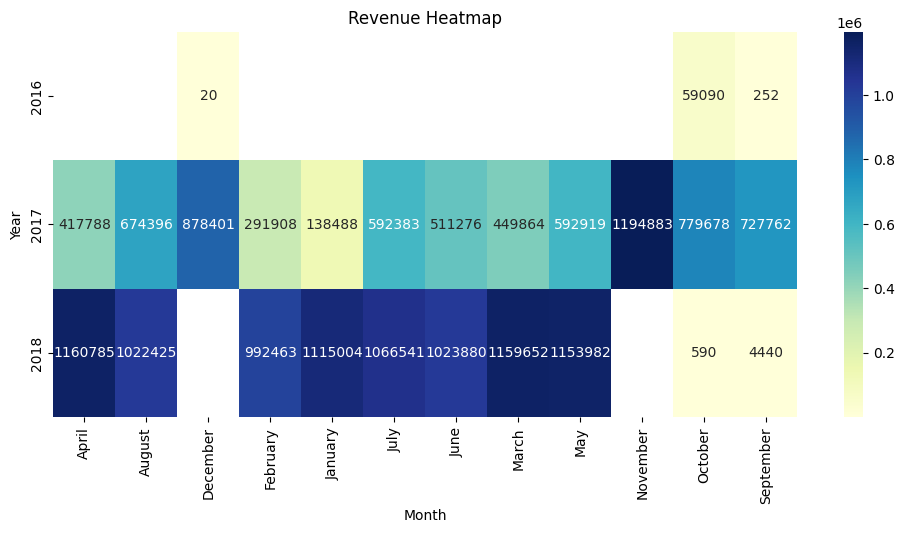

In [72]:
query=""" 
SELECT
YEAR(order_purchase_timestamp) Year,
MONTHNAME(order_purchase_timestamp) Month,
ROUND(SUM(payment_value),2) Revenue
FROM orders
JOIN order_payments
ON orders.order_id=order_payments.order_id
GROUP BY Year,
MONTH(order_purchase_timestamp),
Month
order by revenue desc
 """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["Year","Month","Revenue"])
pivot=df.pivot(index="Year",
columns="Month",
values="Revenue")

import seaborn as sns

plt.figure(figsize=(12,5))
sns.heatmap(pivot,
annot=True,
fmt=".0f",
cmap="YlGnBu"

)

plt.title("Revenue Heatmap")
plt.show()


In [ ]:
""" Insights-
1.Revenue increased significantly from 2017 to 2018, indicating substantial business growth over time.
2.November 2017 recorded the highest monthly revenue of the year, suggesting a strong seasonal sales peak.
3.Revenue remained relatively stable across most months in 2018, showing consistent business performance.
"""